# Battery Charging and Discharge in CAISO’s Spring Duck Curve

This notebook supports the whitepaper: **Battery Charging and Discharge in CAISO’s Spring Duck Curve: A Year-over-Year Comparison**.

The analysis compares April and May operating days from 2021–2025. It examines:

1. Midday battery charging
2. Evening battery discharge
3. Battery discharge relative to the 5–9 PM net-load ramp

This analysis is descriptive, not causal. It does not claim that batteries caused the duck curve to change.

## 1. Setup

In [ ]:
from pathlib import Path
import time
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from gridstatus import CAISO

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 50)

iso = CAISO()

print("Setup Complete")

setup complete


## 2. Project Folders

In [2]:
PROJECT_ROOT = Path("..").resolve()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

for folder in [RAW_DIR, PROCESSED_DIR, FIGURES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DIR)
print("Processed data:", PROCESSED_DIR)
print("Figures:", FIGURES_DIR)

Project root: C:\My Code\Personal\CAISO Battery Discharge Duck Curve Whitepaper\caiso-duck-curve-battery-charging-and-discharging
Raw data: C:\My Code\Personal\CAISO Battery Discharge Duck Curve Whitepaper\caiso-duck-curve-battery-charging-and-discharging\data\raw
Processed data: C:\My Code\Personal\CAISO Battery Discharge Duck Curve Whitepaper\caiso-duck-curve-battery-charging-and-discharging\data\processed
Figures: C:\My Code\Personal\CAISO Battery Discharge Duck Curve Whitepaper\caiso-duck-curve-battery-charging-and-discharging\figures


## 3. Analysis Settings

In [3]:
YEARS = list(range(2021, 2026))
MONTHS = [4, 5]

START_DATE = "2021-04-01"
END_DATE = "2025-05-31"

MIDDAY_HOURS = list(range(10, 15))      # 10 AM through 2 PM
EVENING_HOURS = list(range(17, 21))     # 5 PM through 8:55 PM if 5-min data
RAMP_START_HOUR = 17                    # 5 PM
RAMP_END_HOUR = 21                      # 9 PM endpoint

spring_dates = [
    d for d in pd.date_range(START_DATE, END_DATE, freq="D")
    if d.year in YEARS and d.month in MONTHS
]

print("Years:", YEARS)
print("Number of April/May dates:", len(spring_dates))
print("First date:", spring_dates[0])
print("Last date:", spring_dates[-1])

Years: [2021, 2022, 2023, 2024, 2025]
Number of April/May dates: 305
First date: 2021-04-01 00:00:00
Last date: 2025-05-31 00:00:00


## 4. Data-source note 
This notebook uses public CAISO data accessed through `gridstatus`.

Main variables:
- Load
- Solar generation
- Wind generation
- Battery net output

Battery net output is interpreted as:
- Positive batteries value = battery discharge
- Negative batteries value = battery charging

Net load is calculated as:

net load = load - solar - wind

This analysis is descriptive, not causal. It does not estimate what CAISO would have looked like without batteries.

## 5. Helper functions

In [4]:
def standardize_time_column(df):
    """
    Create a shared interval_start column from common gridstatus time column names.
    """
    df = df.copy()

    possible_time_cols = [
        "Interval Start",
        "Time",
        "IntervalStart",
        "interval_start",
        "time",
    ]

    for col in possible_time_cols:
        if col in df.columns:
            df["interval_start"] = pd.to_datetime(df[col])
            return df

    raise ValueError(f"No recognized time column. Columns: {df.columns.tolist()}")


def find_column(df, possible_names):
    """
    Find a column from a list of possible names.
    Case-insensitive.
    """
    col_map = {col.lower(): col for col in df.columns}

    for name in possible_names:
        if name.lower() in col_map:
            return col_map[name.lower()]

    return None


def clean_day_data(day, force_refresh=False, sleep_seconds=0.25):
    """
    Pull one day of CAISO load and fuel mix data.
    
    Uses fuel mix for solar, wind, and batteries.
    Uses load data for total load.
    Calculates net load and battery charge/discharge.
    """
    day = pd.Timestamp(day).strftime("%Y-%m-%d")
    cache_path = RAW_DIR / f"caiso_{day}.csv"

    if cache_path.exists() and not force_refresh:
        return pd.read_csv(cache_path, parse_dates=["interval_start"])

    print(f"Fetching {day}")

    # Load data
    load = iso.get_load(day)
    load = standardize_time_column(load)

    load_col = find_column(load, ["Load", "load"])
    if load_col is None:
        raise ValueError(f"No load column found for {day}. Columns: {load.columns.tolist()}")

    load = load[["interval_start", load_col]].rename(columns={load_col: "load_mw"})

    # Fuel mix data
    fuel = iso.get_fuel_mix(day)
    fuel = standardize_time_column(fuel)

    solar_col = find_column(fuel, ["Solar", "solar"])
    wind_col = find_column(fuel, ["Wind", "wind"])
    battery_col = find_column(fuel, ["Batteries", "Battery", "batteries", "battery"])

    missing = []
    if solar_col is None:
        missing.append("Solar")
    if wind_col is None:
        missing.append("Wind")
    if battery_col is None:
        missing.append("Batteries")

    if missing:
        raise ValueError(f"Missing columns for {day}: {missing}. Available fuel columns: {fuel.columns.tolist()}")

    fuel = fuel[["interval_start", solar_col, wind_col, battery_col]].rename(
        columns={
            solar_col: "solar_mw",
            wind_col: "wind_mw",
            battery_col: "battery_net_mw",
        }
    )

    # Merge
    df = (
        load
        .merge(fuel, on="interval_start", how="outer")
        .sort_values("interval_start")
        .reset_index(drop=True)
    )

    for col in ["load_mw", "solar_mw", "wind_mw", "battery_net_mw"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Time columns
    df["date"] = df["interval_start"].dt.date
    df["year"] = df["interval_start"].dt.year
    df["month"] = df["interval_start"].dt.month
    df["hour"] = df["interval_start"].dt.hour

    # Net load
    df["net_load_mw"] = df["load_mw"] - df["solar_mw"] - df["wind_mw"]

    # Battery interpretation:
    # Positive = discharge into grid
    # Negative = charging from grid
    df["battery_discharge_mw"] = df["battery_net_mw"].clip(lower=0)
    df["battery_charge_mw"] = (-df["battery_net_mw"]).clip(lower=0)

    df.to_csv(cache_path, index=False)

    time.sleep(sleep_seconds)

    return df

## 6. Fetch all April/May Data, 2021-2025

In [5]:
daily_frames = []
failed_dates = []

for i, day in enumerate(spring_dates, start=1):
    day_str = day.strftime("%Y-%m-%d")
    print(f"[{i}/{len(spring_dates)}] {day_str}")

    try:
        df_day = clean_day_data(day_str, force_refresh=False, sleep_seconds=0.25)
        daily_frames.append(df_day)
    except Exception as e:
        print(f"FAILED {day_str}: {e}")
        failed_dates.append({"date": day_str, "error": str(e)})

print("Successful days:", len(daily_frames))
print("Failed days:", len(failed_dates))

2026-06-19 13:15:40 - INFO - Fetching URL: https://www.caiso.com/outlook/history/20210401/demand.csv?_=1781900140


[1/305] 2021-04-01
Fetching 2021-04-01


2026-06-19 13:15:41 - INFO - Fetching URL: https://www.caiso.com/outlook/history/20210401/fuelsource.csv?_=1781900141
2026-06-19 13:15:41 - INFO - Fetching URL: https://www.caiso.com/outlook/history/20210402/demand.csv?_=1781900141


[2/305] 2021-04-02
Fetching 2021-04-02


2026-06-19 13:15:42 - INFO - Fetching URL: https://www.caiso.com/outlook/history/20210402/fuelsource.csv?_=1781900142
2026-06-19 13:15:42 - INFO - Fetching URL: https://www.caiso.com/outlook/history/20210403/demand.csv?_=1781900142


...

[304/305] 2025-05-30
Fetching 2025-05-30


2026-06-19 13:19:48 - INFO - Fetching URL: https://www.caiso.com/outlook/history/20250530/fuelsource.csv?_=1781900388
2026-06-19 13:19:49 - INFO - Fetching URL: https://www.caiso.com/outlook/history/20250531/demand.csv?_=1781900389


[305/305] 2025-05-31
Fetching 2025-05-31


2026-06-19 13:19:49 - INFO - Fetching URL: https://www.caiso.com/outlook/history/20250531/fuelsource.csv?_=1781900389


Successful days: 305
Failed days: 0


In [6]:
caiso = pd.concat(daily_frames, ignore_index=True)
caiso = caiso.sort_values("interval_start").reset_index(drop=True)

caiso.shape

(87830, 12)

## 7. Save combined processed data

In [7]:
processed_path = PROCESSED_DIR / "caiso_spring_2021_2025_5min.csv"

caiso.to_csv(processed_path, index=False)

processed_path

WindowsPath('C:/My Code/Personal/CAISO Battery Discharge Duck Curve Whitepaper/caiso-duck-curve-battery-charging-and-discharging/data/processed/caiso_spring_2021_2025_5min.csv')

## 8. Data Checks

In [8]:
caiso[[
    "load_mw",
    "solar_mw",
    "wind_mw",
    "net_load_mw",
    "battery_net_mw",
    "battery_charge_mw",
    "battery_discharge_mw",
]].describe()

,load_mw,solar_mw,wind_mw,net_load_mw,battery_net_mw,battery_charge_mw,battery_discharge_mw
count,87830.000000,87830.000000,87830.000000,87830.000000,87830.000000,87830.000000,87830.000000
mean,21908.850051,6037.511966,3277.628123,12593.709962,-38.136662,652.542548,614.405886
std,3267.723076,6555.912321,1417.119653,7922.134030,2148.450677,1346.787621,1414.263879
min,10864.000000,-85.000000,102.000000,-7307.000000,-8342.000000,0.000000,0.000000
25%,19934.000000,-12.000000,2128.000000,5785.000000,-467.000000,0.000000,0.000000
50%,21693.000000,2568.000000,3474.000000,15413.000000,-10.000000,10.000000,0.000000
75%,23824.000000,12100.000000,4409.000000,18794.000000,399.000000,467.000000,399.000000
max,36139.000000,21556.000000,6429.000000,33307.000000,10030.000000,8342.000000,10030.000000


## 9. Create average hourly spring profiles

In [ ]:
hourly_profile = (
    caiso
    .groupby(["year", "hour"], as_index=False)
    .agg(
        load_mw=("load_mw", "mean"),
        solar_mw=("solar_mw", "mean"),
        wind_mw=("wind_mw", "mean"),
        net_load_mw=("net_load_mw", "mean"),
        battery_net_mw=("battery_net_mw", "mean"),
        battery_charge_mw=("battery_charge_mw", "mean"),
        battery_discharge_mw=("battery_discharge_mw", "mean"),
    )
)

,year,hour,load_mw,solar_mw,wind_mw,net_load_mw,battery_net_mw,battery_charge_mw,battery_discharge_mw
0,2021,0,21879.971311,-28.795082,4020.950820,17887.815574,0.590164,25.300546,25.890710
1,2021,1,21021.937158,-28.689891,3934.803279,17115.823770,-21.711749,34.385246,12.673497
2,2021,2,20444.183060,-29.017760,3810.456284,16662.744536,-29.046448,36.367486,7.321038
3,2021,3,20171.389344,-30.132514,3656.591530,16544.930328,-6.696721,23.524590,16.827869
4,2021,4,20344.092896,-31.297814,3507.278689,16868.112022,44.010929,7.851093,51.862022


In [11]:
hourly_profile_path = PROCESSED_DIR / "hourly_profile_2021_2025.csv"

hourly_profile.to_csv(hourly_profile_path, index=False)

hourly_profile_path

WindowsPath('C:/My Code/Personal/CAISO Battery Discharge Duck Curve Whitepaper/caiso-duck-curve-battery-charging-and-discharging/data/processed/hourly_profile_2021_2025.csv')

## 10. Calculate yearly metrics

In [12]:
metrics = []

for year in YEARS:
    hp = hourly_profile[hourly_profile["year"] == year].copy()

    midday = hp[hp["hour"].isin(MIDDAY_HOURS)]
    evening = hp[hp["hour"].isin(EVENING_HOURS)]

    net_load_5pm = hp.loc[hp["hour"] == RAMP_START_HOUR, "net_load_mw"].mean()
    net_load_9pm = hp.loc[hp["hour"] == RAMP_END_HOUR, "net_load_mw"].mean()

    ramp_mw = net_load_9pm - net_load_5pm

    midday_charge_avg_mw = midday["battery_charge_mw"].mean()
    evening_discharge_avg_mw = evening["battery_discharge_mw"].mean()

    solar_midday_avg_mw = midday["solar_mw"].mean()
    solar_5pm_mw = hp.loc[hp["hour"] == 17, "solar_mw"].mean()
    solar_9pm_mw = hp.loc[hp["hour"] == 21, "solar_mw"].mean()
    solar_drop_5_9_mw = solar_5pm_mw - solar_9pm_mw

    battery_ramp_coverage_pct = np.nan
    if pd.notna(ramp_mw) and ramp_mw > 0:
        battery_ramp_coverage_pct = 100 * evening_discharge_avg_mw / ramp_mw

    metrics.append({
        "year": year,
        "midday_charge_avg_mw": midday_charge_avg_mw,
        "evening_discharge_avg_mw": evening_discharge_avg_mw,
        "net_load_5pm_mw": net_load_5pm,
        "net_load_9pm_mw": net_load_9pm,
        "net_load_ramp_5_9_mw": ramp_mw,
        "battery_ramp_coverage_pct": battery_ramp_coverage_pct,
        "solar_midday_avg_mw": solar_midday_avg_mw,
        "solar_5pm_mw": solar_5pm_mw,
        "solar_9pm_mw": solar_9pm_mw,
        "solar_drop_5_9_mw": solar_drop_5_9_mw,
    })

metrics_df = pd.DataFrame(metrics)

metrics_df

,year,midday_charge_avg_mw,evening_discharge_avg_mw,net_load_5pm_mw,net_load_9pm_mw,net_load_ramp_5_9_mw,battery_ramp_coverage_pct,solar_midday_avg_mw,solar_5pm_mw,solar_9pm_mw,solar_drop_5_9_mw
0,2021,103.713115,114.950137,12242.542350,22460.952186,10218.409836,1.124932,11614.483333,8658.620219,-29.527322,8688.147541
1,2022,372.565027,822.805328,10613.907104,22236.956284,11623.049180,7.079083,11560.928142,9447.265027,72.803279,9374.461749
2,2023,1342.044262,1431.590505,9874.360656,22296.886612,12422.525956,11.524150,12261.630055,9407.127049,10.316940,9396.810109
3,2024,3371.510383,2928.086066,5823.745902,21150.183060,15326.437158,19.104806,15481.815027,12467.322404,80.308743,12387.013661
4,2025,5045.949454,4188.008197,6078.797814,22517.312842,16438.515027,25.476804,18036.232514,13666.959016,-27.823770,13694.782787


In [13]:
metrics_path = PROCESSED_DIR / "yearly_metrics_2021_2025.csv"

metrics_df.to_csv(metrics_path, index=False)

metrics_path

WindowsPath('C:/My Code/Personal/CAISO Battery Discharge Duck Curve Whitepaper/caiso-duck-curve-battery-charging-and-discharging/data/processed/yearly_metrics_2021_2025.csv')

## 11. Clean results 

In [14]:
metrics_display = metrics_df.copy()

for col in metrics_display.columns:
    if col != "year":
        metrics_display[col] = metrics_display[col].round(1)

metrics_display

,year,midday_charge_avg_mw,evening_discharge_avg_mw,net_load_5pm_mw,net_load_9pm_mw,net_load_ramp_5_9_mw,battery_ramp_coverage_pct,solar_midday_avg_mw,solar_5pm_mw,solar_9pm_mw,solar_drop_5_9_mw
0,2021,103.7,115.0,12242.5,22461.0,10218.4,1.1,11614.5,8658.6,-29.5,8688.1
1,2022,372.6,822.8,10613.9,22237.0,11623.0,7.1,11560.9,9447.3,72.8,9374.5
2,2023,1342.0,1431.6,9874.4,22296.9,12422.5,11.5,12261.6,9407.1,10.3,9396.8
3,2024,3371.5,2928.1,5823.7,21150.2,15326.4,19.1,15481.8,12467.3,80.3,12387.0
4,2025,5045.9,4188.0,6078.8,22517.3,16438.5,25.5,18036.2,13667.0,-27.8,13694.8


In [15]:
results_table_path = PROCESSED_DIR / "results_table_2021_2025.csv"

metrics_display.to_csv(results_table_path, index=False)

results_table_path

WindowsPath('C:/My Code/Personal/CAISO Battery Discharge Duck Curve Whitepaper/caiso-duck-curve-battery-charging-and-discharging/data/processed/results_table_2021_2025.csv')

## Figure 1: Average Spring Duck Curve

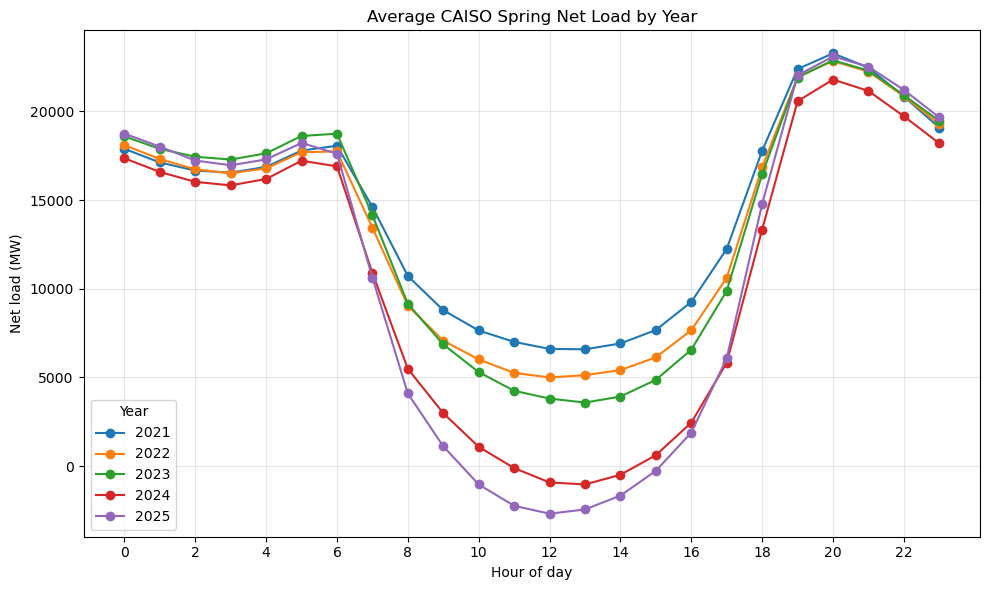

WindowsPath('C:/My Code/Personal/CAISO Battery Discharge Duck Curve Whitepaper/caiso-duck-curve-battery-charging-and-discharging/figures/fig1_average_spring_net_load_by_year.png')

In [16]:
plt.figure(figsize=(10, 6))

for year in YEARS:
    hp = hourly_profile[hourly_profile["year"] == year]
    plt.plot(hp["hour"], hp["net_load_mw"], marker="o", label=str(year))

plt.title("Average CAISO Spring Net Load by Year")
plt.xlabel("Hour of day")
plt.ylabel("Net load (MW)")
plt.xticks(range(0, 24, 2))
plt.legend(title="Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIGURES_DIR / "fig1_average_spring_net_load_by_year.png"
plt.savefig(fig_path, dpi=300)
plt.show()

fig_path

## Figure 2: Average Solar Profile

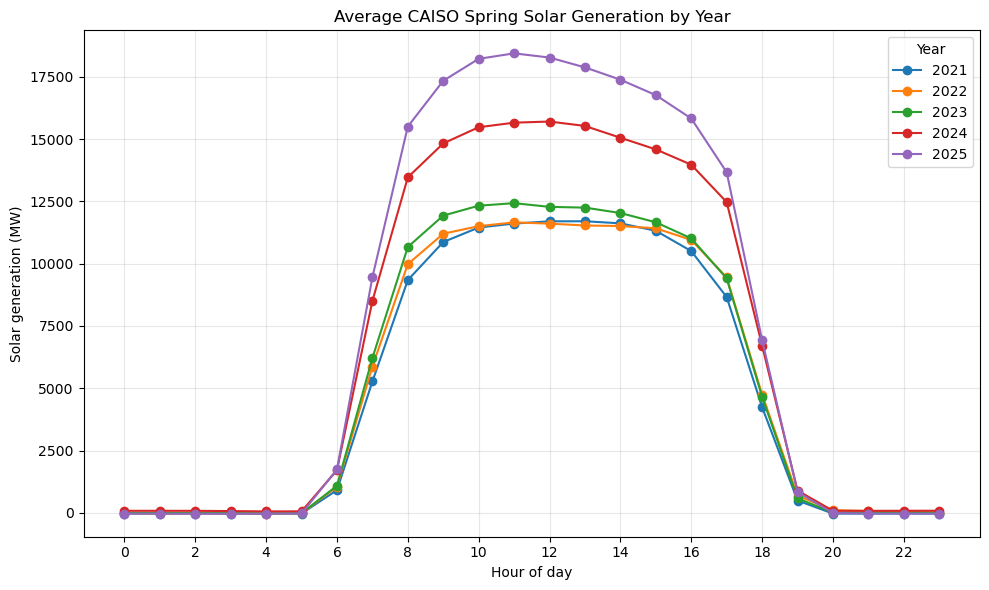

WindowsPath('C:/My Code/Personal/CAISO Battery Discharge Duck Curve Whitepaper/caiso-duck-curve-battery-charging-and-discharging/figures/fig2_average_spring_solar_by_year.png')

In [17]:
plt.figure(figsize=(10, 6))

for year in YEARS:
    hp = hourly_profile[hourly_profile["year"] == year]
    plt.plot(hp["hour"], hp["solar_mw"], marker="o", label=str(year))

plt.title("Average CAISO Spring Solar Generation by Year")
plt.xlabel("Hour of day")
plt.ylabel("Solar generation (MW)")
plt.xticks(range(0, 24, 2))
plt.legend(title="Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIGURES_DIR / "fig2_average_spring_solar_by_year.png"
plt.savefig(fig_path, dpi=300)
plt.show()

fig_path

## Figure 3: Battery Charging Profile

In [ ]:
plt.figure(figsize=(10, 6))

for year in YEARS:
    hp = hourly_profile[hourly_profile["year"] == year]
    plt.plot(hp["hour"], hp["battery_charge_mw"], marker="o", label=str(year))

plt.title("Average CAISO Spring Battery Charging by Year")
plt.xlabel("Hour of day")
plt.ylabel("Battery charging (MW)")
plt.xticks(range(0, 24, 2))
plt.legend(title="Year")
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIGURES_DIR / "fig3_average_battery_charging_by_year.png"
plt.savefig(fig_path, dpi=300)
plt.show()

fig_path